#GAURAV KUMAR
#2501940033
#Deep Learning Architectures and Techniques (ETMMDL274)
---------------------------------------------------------------------------------------------
# **ASSIGNMENT - 1**
##**Neural Network–Based Credit Risk Prediction Using a Multi-Layer Perceptron (MLP)**
This laboratory assignment focuses on the practical implementation of feedforward neural
networks for binary classification using structured/tabular data. Students will build, train, and
evaluate a Multi-Layer Perceptron (MLP) to predict credit risk, reinforcing core Unit 1
concepts such as neurons, activation functions, loss functions, and optimization.


Epoch 1/30


/tmp/ipykernel_160/4270082058.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method="ffill", inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5320 - loss: 0.7334 - val_accuracy: 0.6750 - val_loss: 0.6765
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6463 - loss: 0.6877 - val_accuracy: 0.6875 - val_loss: 0.6420
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6892 - loss: 0.6385 - val_accuracy: 0.6938 - val_loss: 0.6189
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7100 - loss: 0.5984 - val_accuracy: 0.6938 - val_loss: 0.6004
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7226 - loss: 0.5825 - val_accuracy: 0.6938 - val_loss: 0.5868
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7130 - loss: 0.5572 - val_accuracy: 0.6875 - val_loss: 0.5750
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7243 - loss: 0.5384 - val_accuracy: 0.7125 - val_loss: 0.5640
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7234 - loss: 0.5316 - val_accuracy: 0.7063 - val_loss: 0.5534
Ep

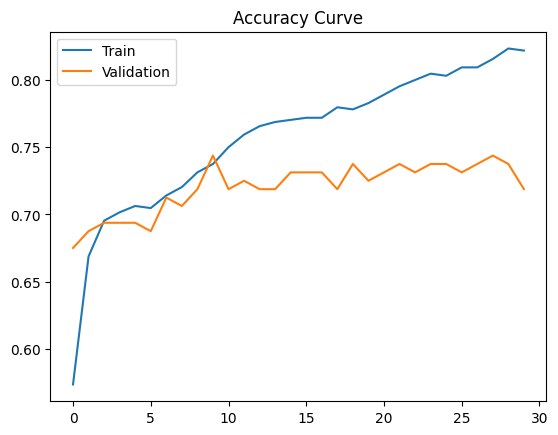

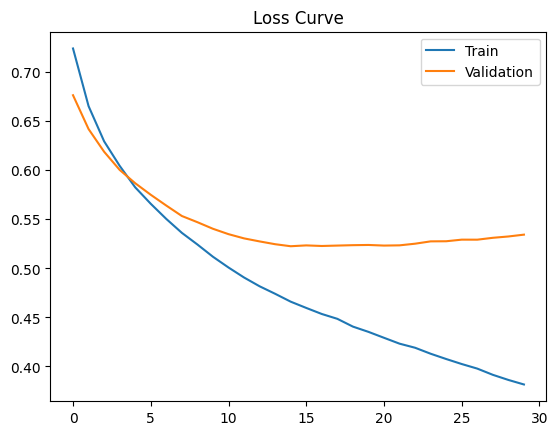

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


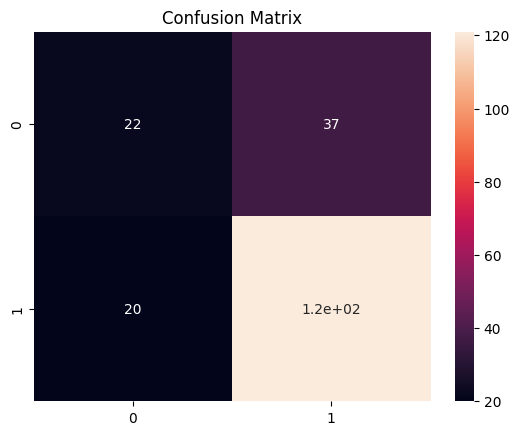

              precision    recall  f1-score   support

           0       0.52      0.37      0.44        59
           1       0.77      0.86      0.81       141

    accuracy                           0.71       200
   macro avg       0.64      0.62      0.62       200
weighted avg       0.69      0.71      0.70       200



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
data = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv")

# Handle missing values
data.fillna(method="ffill", inplace=True)

# Encode categorical features
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop("credit_risk", axis=1)
y = data["credit_risk"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

# Build MLP
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

# Create directory for plots if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.legend(["Train", "Validation"])
plt.savefig("plots/accuracy_curve.png")
plt.show()

# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(["Train", "Validation"])
plt.savefig("plots/loss_curve.png")
plt.show()

# Predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.savefig("plots/confusion_matrix.png")
plt.show()

print(classification_report(y_test, y_pred))